#### LSTM Encoder

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    RepeatVector,
    TimeDistributed,
    Dense
)

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Load Feature Dataset
cpu_df = pd.read_csv(
    "../data/Processed/cpu_features.csv"
)

cpu_df["ts"] = pd.to_datetime(
    cpu_df["ts"],
    format="mixed",
    utc=True
)

cpu_df.shape

(74252, 27)

In [3]:
# Sort Data
cpu_df = cpu_df.sort_values(
    ["hostName", "ts"]
).reset_index(drop=True)

In [4]:
# Features for autoencoder
FEATURES = [

    "cpu_usage_pct",

    "memory_usage_pct",

    "power_kw",

    "cpu_temp_c",

    "inlet_temp_c",

    "cpu_change",

    "cpu_acceleration",

    "cpu_volatility",

    "cpu_memory_ratio",

    "thermal_gradient",

    "temp_rate_of_change",

    "cpu_per_kw",

    "temp_per_cpu",

    "resource_stress_index"

]

In [5]:
# Scaling
scaler = MinMaxScaler()
cpu_df[FEATURES] = scaler.fit_transform(
    cpu_df[FEATURES]
)

In [6]:
# Sequence Creation
SEQ_LEN = 12
X = []
timestamps = []
hosts = []

for host in cpu_df["hostName"].unique():

    host_df = (
        cpu_df[
            cpu_df["hostName"] == host
        ]
        .sort_values("ts")
    )

    values = host_df[FEATURES].values

    for i in range(
        len(values) - SEQ_LEN
    ):

        X.append(
            values[i:i+SEQ_LEN]
        )

        timestamps.append(
            host_df.iloc[i+SEQ_LEN]["ts"]
        )

        hosts.append(host)

X = np.array(X)

print(X.shape)

(74216, 12, 14)


In [7]:
# Train-test split
split_idx = int(
    len(X) * 0.8
)

X_train = X[:split_idx]

X_test = X[split_idx:]

In [9]:
# Autoencoder Architecture
inputs = Input(
    shape=(SEQ_LEN, len(FEATURES))
)

# Encoder
encoded = LSTM(
    64,
    activation="relu",
    return_sequences=True
)(inputs)

encoded = LSTM(
    32,
    activation="relu"
)(encoded)

# Bottleneck
bottleneck = RepeatVector(
    SEQ_LEN
)(encoded)

# Decoder
decoded = LSTM(
    32,
    activation="relu",
    return_sequences=True
)(bottleneck)

decoded = LSTM(
    64,
    activation="relu",
    return_sequences=True
)(decoded)

decoded = TimeDistributed(
    Dense(len(FEATURES))
)(decoded)

# Model
autoencoder = Model(
    inputs,
    decoded
)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 12, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 12, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 12, 14)         │           910 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,702 (260.55 KB)

 Trainable params: 66,702 (260.55 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
history = autoencoder.fit(
    X_train,
    X_train,

    epochs=30,

    batch_size=128,

    validation_split=0.2,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0173 - val_loss: 0.0035
Epoch 2/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0029 - val_loss: 0.0034
Epoch 3/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 4/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 5/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 6/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 7/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0027 - val_loss: 0.0023
Epoch 8/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 9/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 10/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 11/30
372/372 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 12/30
372/372 ━━━━━━━━━━━━━━━━━━━

In [11]:
# Reconstruction
X_pred = autoencoder.predict(
    X_test
)
# Reconstruction error
mse = np.mean(
    np.square(
        X_test - X_pred
    ),
    axis=(1,2)
)

464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


In [12]:
# Threshold
threshold = np.percentile(
    mse,
    99
)

print(
    "Threshold:",
    threshold
)

Threshold: 0.006895036497172545


In [13]:
# Flag anomalies
anomaly_flags = (
    mse > threshold
)

In [14]:
# Build results dataframe
results = pd.DataFrame({

    "timestamp":
    timestamps[split_idx:],

    "hostName":
    hosts[split_idx:],

    "reconstruction_error":
    mse,

    "anomaly":
    anomaly_flags
})

In [ ]:
# Count anomalies
results["anomaly"].value_counts()

anomaly
False    14695
True       149
Name: count, dtype: int64

In [16]:
# Extract anomalies
anomalies = results[
    results["anomaly"]
]

anomalies.head()

,timestamp,hostName,reconstruction_error,anomaly
1076,2026-04-24 09:18:14.915000+00:00,10.10.10.65,0.008278,True
1077,2026-04-24 09:23:15.638000+00:00,10.10.10.65,0.012300,True
1078,2026-04-24 09:28:38.983000+00:00,10.10.10.65,0.012978,True
1079,2026-04-24 09:33:14.907000+00:00,10.10.10.65,0.016163,True
1080,2026-04-24 09:38:26.376000+00:00,10.10.10.65,0.019293,True


C:\Users\Avilasha\AppData\Local\Temp\ipykernel_34224\3440932705.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


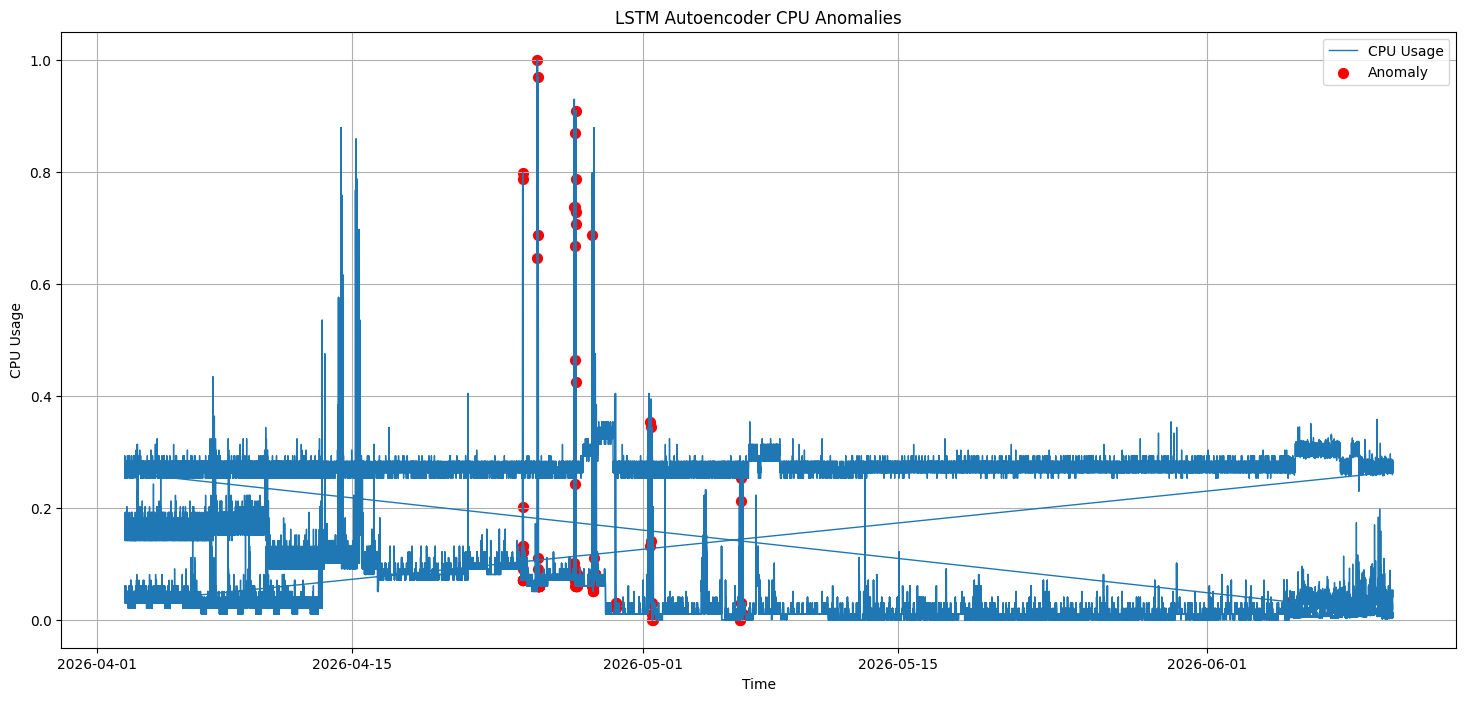

In [17]:
# CPU Line Plot with Flagged anomalies
# create lookup
cpu_lookup = cpu_df[
    [
        "ts",
        "hostName",
        "cpu_usage_pct"
    ]
].copy()
# merge
plot_df = pd.merge(
    cpu_lookup,

    results,

    left_on=[
        "ts",
        "hostName"
    ],

    right_on=[
        "timestamp",
        "hostName"
    ],

    how="left"
)
# fill
plot_df["anomaly"] = (
    plot_df["anomaly"]
    .fillna(False)
)
# plot
plt.figure(
    figsize=(18,8)
)

plt.plot(
    plot_df["ts"],
    plot_df["cpu_usage_pct"],
    linewidth=1,
    label="CPU Usage"
)

anomaly_points = plot_df[
    plot_df["anomaly"]
]

plt.scatter(
    anomaly_points["ts"],
    anomaly_points["cpu_usage_pct"],
    color="red",
    s=50,
    label="Anomaly"
)

plt.title(
    "LSTM Autoencoder CPU Anomalies"
)

plt.xlabel("Time")

plt.ylabel("CPU Usage")

plt.legend()

plt.grid(True)

plt.show()

In [18]:
# Extract flagged events
anomalies[
    [
        "timestamp",
        "hostName",
        "reconstruction_error"
    ]
].sort_values(
    "reconstruction_error",
    ascending=False
).head(50)

,timestamp,hostName,reconstruction_error
1316,2026-04-25 05:18:15.133000+00:00,10.10.10.65,0.039114
1905,2026-04-27 06:23:29.334000+00:00,10.10.10.65,0.038302
1315,2026-04-25 05:13:22.789000+00:00,10.10.10.65,0.037811
1320,2026-04-25 05:38:25.530000+00:00,10.10.10.65,0.037720
1318,2026-04-25 05:28:14.946000+00:00,10.10.10.65,0.037242
1921,2026-04-27 07:43:15.263000+00:00,10.10.10.65,0.036930
1319,2026-04-25 05:33:23.291000+00:00,10.10.10.65,0.036360
1317,2026-04-25 05:23:14.936000+00:00,10.10.10.65,0.036328
1915,2026-04-27 07:13:29.655000+00:00,10.10.10.65,0.036187
1914,2026-04-27 07:08:28.498000+00:00,10.10.10.65,0.035353


In [19]:
# TOP anomaly timeline
top_anomalies = anomalies.nlargest(
    20,
    "reconstruction_error"
)

print(
    top_anomalies[
        [
            "timestamp",
            "hostName",
            "reconstruction_error"
        ]
    ]
)

                            timestamp     hostName  reconstruction_error
1316 2026-04-25 05:18:15.133000+00:00  10.10.10.65              0.039114
1905 2026-04-27 06:23:29.334000+00:00  10.10.10.65              0.038302
1315 2026-04-25 05:13:22.789000+00:00  10.10.10.65              0.037811
1320 2026-04-25 05:38:25.530000+00:00  10.10.10.65              0.037720
1318 2026-04-25 05:28:14.946000+00:00  10.10.10.65              0.037242
1921 2026-04-27 07:43:15.263000+00:00  10.10.10.65              0.036930
1319 2026-04-25 05:33:23.291000+00:00  10.10.10.65              0.036360
1317 2026-04-25 05:23:14.936000+00:00  10.10.10.65              0.036328
1915 2026-04-27 07:13:29.655000+00:00  10.10.10.65              0.036187
1914 2026-04-27 07:08:28.498000+00:00  10.10.10.65              0.035353
1906 2026-04-27 06:28:26.800000+00:00  10.10.10.65              0.034793
1920 2026-04-27 07:38:29.839000+00:00  10.10.10.65              0.034358
1904 2026-04-27 06:18:24.310000+00:00  10.10.10.65 